In [1]:
from pathlib import Path
import os
import re
import gc
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import LinearSVR
from sklearn.base import clone
from scipy import sparse

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TRAIN_PATH = 'train_3.csv'

TEST_PATH = 'test_3.csv'

TARGET = 'salary_mean_net'
ID_COL = 'id'
SUBMISSION_PATH = 'submission_salary_mean_net.csv'

print('TRAIN_PATH:', TRAIN_PATH)
print('TEST_PATH:', TEST_PATH)
print('SUBMISSION_PATH:', SUBMISSION_PATH)


TRAIN_PATH: train_3.csv
TEST_PATH: test_3.csv
SUBMISSION_PATH: submission_salary_mean_net.csv


## 1. Загрузка данных

In [2]:
train = pd.read_csv(TRAIN_PATH)
print(train.shape)
display(train.head())
print(train.dtypes)


(49051, 26)


,id,name,employer_name,experience_name,schedule_name,key_skills_name,accept_handicapped,accept_kids,unified_address_city,unified_address_state,...,raw_branded_description,lemmaized_wo_stopwords_raw_description,lemmaized_wo_stopwords_raw_branded_description,if_foreign_language,is_branded_description,name_clean,employment_name,employer_id,employer_industries,salary_mean_net
0,49443602,Помощник в мастерскую (производство кожгаланте...,Кутузова Юлия Евгеньевна,Нет опыта,Полный день,шитьё,True,False,Москва,Москва,...,NaN,обязанность помогать мастер обрезать нитка про...,NaN,Не указано,заполнено,помощник мастерская производство кожгалантерея...,Полная занятость,4959035.0,не указано,35000.0
1,44210403,Сварщик,Весстрой,Нет опыта,Вахтовый метод,организационные навыки,False,False,NaN,Башкортостан,...,NaN,вахта подмосковье объект федеральный значение ...,NaN,Не указано,заполнено,сварщик,Полная занятость,4540012.0,не указано,72500.0
2,48784801,Специалист службы поддержки пользователей,Яндекс Крауд,Нет опыта,Удаленная работа,работа с большим объемом информации,True,False,NaN,Башкортостан,...,NaN,важно случай причина пользователь терять досту...,NaN,Не указано,заполнено,специалист служба поддержка пользователь,Частичная занятость,9498112.0,не указано,11310.0
3,43126202,Слесарь-ремонтник,Киевское,Нет опыта,Полный день,пользователь пк,False,False,Москва,Москва,...,NaN,функционал обслуживание система водоснабжение ...,NaN,Не указано,заполнено,слесарить ремонтник,Полная занятость,3161468.0,не указано,33930.0
4,41164202,Врач-педиатр участковый (п.Снежный),КГБУЗ Комсомольская межрайонная больница МЗ ХК,Нет опыта,Полный день,умение работать в коллективе,False,False,NaN,Сахалинская область,...,NaN,обязанность оказание медико санитарный лечебны...,NaN,Не указано,заполнено,врач педиатр участковый п. снежный,Полная занятость,1710902.0,лечебно-профилактические учреждения,70000.0


id                                                  int64
name                                                  str
employer_name                                         str
experience_name                                       str
schedule_name                                         str
key_skills_name                                       str
accept_handicapped                                   bool
accept_kids                                          bool
unified_address_city                                  str
unified_address_state                                 str
unified_address_region                                str
unified_address_country                               str
specializations_profarea_name                         str
professional_roles_name                               str
languages_name                                        str
raw_description                                       str
raw_branded_description                               str
lemmaized_wo_s

In [3]:
assert TARGET in train.columns, f'В train нет target-колонки {TARGET}'
assert ID_COL in train.columns, f'В train нет ID-колонки {ID_COL}'

if TEST_PATH is not None:
    test = pd.read_csv(TEST_PATH)
    print('test shape:', test.shape)
    display(test.head())
else:
    test = None
    print('Тестовый файл не найден. Ноутбук можно прогнать до CV; для submission положи test.csv рядом с train.')


test shape: (12263, 25)


,name,employer_name,experience_name,schedule_name,key_skills_name,accept_handicapped,accept_kids,unified_address_city,unified_address_state,unified_address_region,...,raw_branded_description,lemmaized_wo_stopwords_raw_description,lemmaized_wo_stopwords_raw_branded_description,if_foreign_language,is_branded_description,name_clean,employment_name,employer_id,employer_industries,id
0,Менеджер по работе с клиентами,ГРУППА КОМПАНИЙ ПРОСТОР,Нет опыта,Полный день,не указано,False,False,Москва,Москва,Центральный федеральный округ,...,более 20 лет успешной работы на рынке недвижим...,продавать недвижимость престижно прибыльно выб...,20 год успешный работа рынок недвижимость 6 оф...,Не указано,не заполнено,менеджер работа клиент,Полная занятость,1087973.0,агентские услуги в недвижимости,46224201
1,Водитель-экспедитор (по доставке товаров до то...,"МАГНИТ, Розничная сеть",От 1 года до 3 лет,Сменный график,автомобильные грузоперевозки,False,False,Казань,Татарстан,Приволжский федеральный округ,...,В связи с расширением штата Автотранспортное п...,связь расширение штат автотранспортный предпри...,связь расширение штат автотранспортный предпри...,Не указано,не заполнено,водитель экспедитор доставка товар торговый об...,Полная занятость,49357.0,аксессуары,42119402
2,"Продавец-кассир (ул. Московский пр-т, д.17)",Группа Компаний Русский Аппетит,Нет опыта,Полный день,точность и внимательность к деталям,False,False,Воронеж,Воронежская область,Центральный федеральный округ,...,группа компаний 20 лет стабильной работы 500 с...,русский аппетит сеть киоск быстрый питание 20-...,группа компания 20 год стабильный работа 500 с...,Не указано,не заполнено,продавец кассир ул. московский пр д.17,Полная занятость,51333.0,кондитерские изделия,45716401
3,Кладовщик,Сибирская медицинская компания,Нет опыта,Полный день,не указано,False,False,Барнаул,Алтайский край,Сибирский федеральный округ,...,NaN,обязанность приём хранение отпуск товарный мат...,NaN,Не указано,заполнено,кладовщик,Полная занятость,2004417.0,не указано,43716203
4,Специалист по обучению персонала,ФГБУ Детский медицинский центр,Нет опыта,Полный день,индивидуальное обучение,False,False,Москва,Москва,Центральный федеральный округ,...,NaN,обязанность организация процесс обучение нмо п...,NaN,Не указано,заполнено,специалист обучение персонал,Полная занятость,2104445.0,не указано,47109602


## 2. Быстрая EDA и sanity-check

Смотрим пропуски, распределение таргета и подозрительные значения. Для MAPE особенно важно не сломаться на маленьких зарплатах, потому что маленький знаменатель превращает ошибку в карнавал боли.

In [4]:
print('Rows:', len(train), 'Columns:', train.shape[1])
print('Missing share:')
display(train.isna().mean().sort_values(ascending=False).to_frame('missing_share').head(30))

print('Target describe:')
display(train[TARGET].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]).to_frame())

print('Non-positive target count:', (train[TARGET] <= 0).sum())


Rows: 49051 Columns: 26
Missing share:


,missing_share
lemmaized_wo_stopwords_raw_branded_description,0.918738
raw_branded_description,0.918738
unified_address_city,0.234593
employer_id,0.000877
unified_address_region,0.000122
experience_name,0.000000
name,0.000000
employer_name,0.000000
schedule_name,0.000000
id,0.000000


Target describe:


,salary_mean_net
count,49051.000000
mean,51094.688580
std,29617.803081
min,10931.550000
1%,13485.000000
5%,19500.000000
10%,22620.000000
25%,30000.000000
50%,42920.000000
75%,64000.000000


Non-positive target count: 0


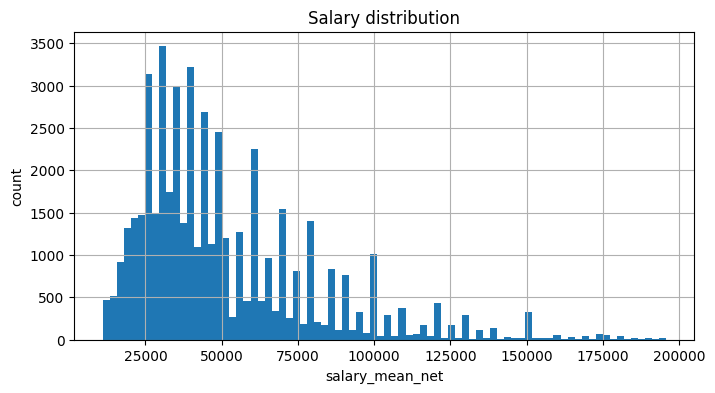

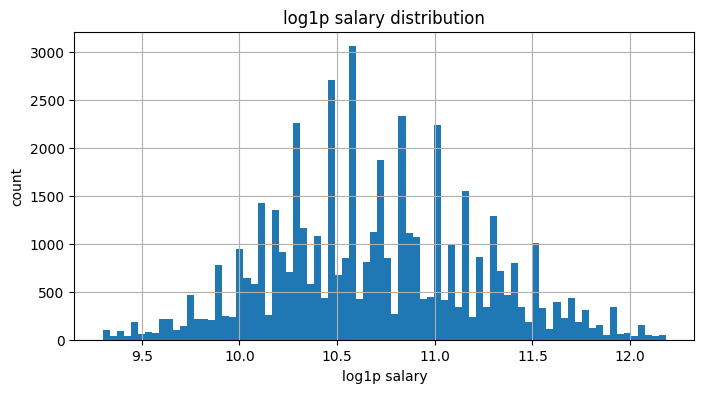

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
train[TARGET].hist(bins=80)
plt.title('Salary distribution')
plt.xlabel(TARGET)
plt.ylabel('count')
plt.show()

plt.figure(figsize=(8,4))
np.log1p(train[TARGET]).hist(bins=80)
plt.title('log1p salary distribution')
plt.xlabel('log1p salary')
plt.ylabel('count')
plt.show()


## 3. Фичи

Идея:

1. Текстовые поля вакансии → TF-IDF.
2. Категориальные поля → OneHotEncoder.
3. Числовые и булевы поля → заполнение пропусков + scaler.
4. Дополнительные простые признаки: длина описания, количество навыков, наличие брендинга и т.п.

Всё строится только на данных соревнования, без внешних источников. Даже интернет не трогаем, какая редкая дисциплина для XXI века.

In [6]:
def clean_text(x):
    if pd.isna(x):
        return ''
    x = str(x).lower()
    x = re.sub(r'<[^>]+>', ' ', x)
    x = re.sub(r'http\S+|www\.\S+', ' ', x)
    x = re.sub(r'[^a-zа-яё0-9+#/\.\- ]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Текстовые композиты. Если есть лемматизированное описание, оно обычно полезнее сырого.
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('').astype(str)
    
    text_parts = []
    for col in [
        'name_clean', 'name', 'key_skills_name', 'professional_roles_name',
        'specializations_profarea_name', 'lemmaized_wo_stopwords_raw_description',
        'raw_description', 'employer_industries'
    ]:
        if col in df.columns:
            text_parts.append(df[col].map(clean_text))
    
    if text_parts:
        df['text_all'] = text_parts[0]
        for part in text_parts[1:]:
            df['text_all'] = df['text_all'] + ' ' + part
    else:
        df['text_all'] = ''
    
    if 'name_clean' in df.columns:
        df['text_title'] = df['name_clean'].map(clean_text)
    elif 'name' in df.columns:
        df['text_title'] = df['name'].map(clean_text)
    else:
        df['text_title'] = ''
    
    # Простые числовые признаки по тексту.
    base_desc = df['raw_description'] if 'raw_description' in df.columns else df['text_all']
    skills = df['key_skills_name'] if 'key_skills_name' in df.columns else pd.Series([''] * len(df), index=df.index)
    df['desc_len'] = base_desc.astype(str).str.len()
    df['desc_words'] = base_desc.astype(str).str.split().str.len()
    df['title_len'] = df['text_title'].astype(str).str.len()
    df['skills_len'] = skills.astype(str).str.len()
    df['skills_count'] = skills.astype(str).apply(lambda s: 0 if s.strip()=='' else len(re.split(r'[,;|/]+', s)))
    
    # Флаги по вакансиям, которые часто коррелируют с уровнем зарплаты.
    text = df['text_all']
    df['has_senior'] = text.str.contains(r'senior|ведущ|старш|lead|principal', regex=True).astype(int)
    df['has_middle'] = text.str.contains(r'middle|мидл', regex=True).astype(int)
    df['has_junior'] = text.str.contains(r'junior|джун|стаж[её]р|intern', regex=True).astype(int)
    df['has_remote'] = text.str.contains(r'удален|удалён|remote|дистанц', regex=True).astype(int)
    df['has_python'] = text.str.contains(r'python|питон', regex=True).astype(int)
    df['has_sql'] = text.str.contains(r'sql|postgres|mysql|clickhouse|oracle', regex=True).astype(int)
    df['has_java'] = text.str.contains(r'java|spring', regex=True).astype(int)
    df['has_sales'] = text.str.contains(r'продаж|sales|клиент', regex=True).astype(int)
    df['has_manager'] = text.str.contains(r'менеджер|manager|руководител|lead', regex=True).astype(int)
    
    # employer_id иногда число, но по смыслу это категория. Оставим отдельную строковую версию.
    if 'employer_id' in df.columns:
        df['employer_id_cat'] = df['employer_id'].fillna(-1).astype('int64').astype(str)
    
    return df

train_fe = add_features(train)
if test is not None:
    test_fe = add_features(test)

print(train_fe[['text_title','desc_len','skills_count','has_senior','has_junior']].head())


                                          text_title  desc_len  skills_count  \
0  помощник мастерская производство кожгалантерея...       444             1   
1                                            сварщик       503             1   
2           специалист служба поддержка пользователь      1212             1   
3                                слесарить ремонтник      1218             1   
4                 врач педиатр участковый п. снежный       806             1   

   has_senior  has_junior  
0           0           0  
1           0           0  
2           0           0  
3           0           0  
4           0           0  


## 4. Разделение колонок по типам

In [7]:
drop_cols = {TARGET, ID_COL}

text_cols = [c for c in ['text_title', 'text_all'] if c in train_fe.columns]

numeric_cols = [
    c for c in train_fe.columns
    if c not in drop_cols and c not in text_cols and pd.api.types.is_numeric_dtype(train_fe[c])
]

# Для OneHot берем не все исходные тексты, а смысловые категории. Сырые длинные описания идут в TF-IDF.
cat_candidates = [
    'employer_name', 'experience_name', 'schedule_name', 'unified_address_city',
    'unified_address_state', 'unified_address_region', 'unified_address_country',
    'specializations_profarea_name', 'professional_roles_name', 'languages_name',
    'if_foreign_language', 'is_branded_description', 'employment_name',
    'employer_industries', 'employer_id_cat'
]
cat_cols = [c for c in cat_candidates if c in train_fe.columns]

print('text_cols:', text_cols)
print('numeric_cols:', numeric_cols)
print('cat_cols:', cat_cols)


text_cols: ['text_title', 'text_all']
numeric_cols: ['accept_handicapped', 'accept_kids', 'employer_id', 'desc_len', 'desc_words', 'title_len', 'skills_len', 'skills_count', 'has_senior', 'has_middle', 'has_junior', 'has_remote', 'has_python', 'has_sql', 'has_java', 'has_sales', 'has_manager']
cat_cols: ['employer_name', 'experience_name', 'schedule_name', 'unified_address_city', 'unified_address_state', 'unified_address_region', 'unified_address_country', 'specializations_profarea_name', 'professional_roles_name', 'languages_name', 'if_foreign_language', 'is_branded_description', 'employment_name', 'employer_industries', 'employer_id_cat']


## 5. Preprocessor: TF-IDF + OneHot + numeric

Параметры TF-IDF можно крутить. Обычно для таких задач хорошо работают слова и короткие n-граммы. Char n-grams тоже часто помогают на вакансиях, потому что названия должностей пишут как попало, видимо, чтобы HR-хаос был виден даже машинам.

In [8]:
# Совместимость с разными версиями sklearn: sparse_output появился не везде.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', min_frequency=5, sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', min_frequency=5, sparse=True)

# Отдельные TF-IDF для title и общего текста.
transformers = []

if 'text_title' in text_cols:
    transformers.append((
        'tfidf_title',
        TfidfVectorizer(max_features=30_000, ngram_range=(1, 3), min_df=2, sublinear_tf=True),
        'text_title'
    ))

if 'text_all' in text_cols:
    transformers.append((
        'tfidf_all_word',
        TfidfVectorizer(max_features=120_000, ngram_range=(1, 2), min_df=3, max_df=0.95, sublinear_tf=True),
        'text_all'
    ))
    transformers.append((
        'tfidf_all_char',
        TfidfVectorizer(max_features=80_000, analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True),
        'text_all'
    ))

if cat_cols:
    transformers.append((
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('ohe', make_ohe())
        ]),
        cat_cols
    ))

if numeric_cols:
    transformers.append((
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False))
        ]),
        numeric_cols
    ))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop',
    sparse_threshold=0.3,
    verbose_feature_names_out=False
)

print(preprocessor)


ColumnTransformer(transformers=[('tfidf_title',
                                 TfidfVectorizer(max_features=30000, min_df=2,
                                                 ngram_range=(1, 3),
                                                 sublinear_tf=True),
                                 'text_title'),
                                ('tfidf_all_word',
                                 TfidfVectorizer(max_df=0.95,
                                                 max_features=120000, min_df=3,
                                                 ngram_range=(1, 2),
                                                 sublinear_tf=True),
                                 'text_all'),
                                ('tfidf_all_char',
                                 TfidfVectorizer(analyzer='char_wb',
                                                 max_features=80000, min_df=3,
                                                 ngr...
                                 Pipeline(steps=[('impu

## 6. Метрика и CV-функции

In [9]:
def mape_salary(y_true, y_pred):
    y_pred = np.asarray(y_pred)
    y_pred = np.clip(y_pred, 1, None)
    return mean_absolute_percentage_error(y_true, y_pred)


def cv_model(model, X, y, n_splits=5, model_name='model'):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X))
    scores = []
    fitted_models = []
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        est = clone(model)
        est.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(est.predict(X_val))
        pred = np.clip(pred, 1, None)
        
        score = mape_salary(y_val, pred)
        scores.append(score)
        oof[val_idx] = pred
        fitted_models.append(est)
        print(f'{model_name} | fold {fold}: MAPE={score:.5f}')
        gc.collect()
    
    print(f'{model_name} | mean={np.mean(scores):.5f}, std={np.std(scores):.5f}')
    return oof, scores, fitted_models


## 7. Бейзлайн: медиана

Нужен, чтобы понимать, не занимаемся ли мы сложной формой самоунижения.

In [11]:
X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET].astype(float)

median_pred = np.full(len(y), y.median())
print('Median baseline MAPE:', mape_salary(y, median_pred))


Median baseline MAPE: 0.45020081846562615


## 8. Основная модель 1: Ridge на sparse-признаках

Для текстовых задач Ridge часто даёт мощный стабильный результат. Он скучный, зато не делает вид, что понимает смысл жизни.

In [13]:
ridge_model = Pipeline([
    ('features', preprocessor),
    ('model', Ridge(alpha=8.0, random_state=RANDOM_STATE))
])

oof_ridge, scores_ridge, ridge_folds = cv_model(ridge_model, X, y, n_splits=1, model_name='Ridge TFIDF')


ValueError: k-fold cross-validation requires at least one train/test split by setting n_splits=2 or more, got n_splits=1.

## 9. Дополнительная модель 2: ElasticNet / LinearSVR

Если времени мало, можно не запускать. Но иногда в ансамбле даёт небольшой плюс.

In [17]:
RUN_EXTRA_LINEAR = True

if RUN_EXTRA_LINEAR:
    enet_model = Pipeline([
        ('features', preprocessor),
        ('model', ElasticNet(alpha=0.00015, l1_ratio=0.03, random_state=RANDOM_STATE, max_iter=3000))
    ])
    oof_enet, scores_enet, enet_folds = cv_model(enet_model, X, y, n_splits=2, model_name='ElasticNet TFIDF')
else:
    oof_enet, scores_enet, enet_folds = None, None, []


ElasticNet TFIDF | fold 1: MAPE=0.23244
ElasticNet TFIDF | fold 2: MAPE=0.23138
ElasticNet TFIDF | mean=0.23191, std=0.00053


## 10. Бустинг по компактным признакам: LightGBM

LightGBM плохо переваривает огромный sparse TF-IDF напрямую в учебных ноутбуках, поэтому для него делаем компактный набор: числовые + категориальные + top TF-IDF/SVD можно добавить. Ниже вариант без внешних данных и без нейронок.

Если LightGBM не установлен, ячейка пропустится.

In [12]:
try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception as e:
    HAS_LGB = False
    print('LightGBM unavailable:', e)

# Для бустинга используем tabular-фичи + короткий TF-IDF по названию/скиллам через sparse матрицу.
boost_text_cols = [c for c in ['text_title', 'key_skills_name', 'professional_roles_name', 'specializations_profarea_name'] if c in train_fe.columns]
train_boost = train_fe.copy()
if test is not None:
    test_boost = test_fe.copy()

boost_cat_cols = cat_cols.copy()
boost_num_cols = numeric_cols.copy()

print('HAS_LGB:', HAS_LGB)
print('boost_text_cols:', boost_text_cols)


HAS_LGB: True
boost_text_cols: ['text_title', 'key_skills_name', 'professional_roles_name', 'specializations_profarea_name']


In [13]:
from sklearn.decomposition import TruncatedSVD

RUN_LGB = HAS_LGB

if RUN_LGB:
    # Компактный текст для SVD.
    train_boost['boost_text'] = ''
    for c in boost_text_cols:
        train_boost['boost_text'] += ' ' + train_boost[c].fillna('').astype(str).map(clean_text)
    
    tfidf_boost = TfidfVectorizer(max_features=50_000, ngram_range=(1,2), min_df=3, sublinear_tf=True)
    X_text = tfidf_boost.fit_transform(train_boost['boost_text'])
    svd = TruncatedSVD(n_components=128, random_state=RANDOM_STATE)
    X_svd = svd.fit_transform(X_text)
    svd_cols = [f'svd_{i}' for i in range(X_svd.shape[1])]
    train_svd = pd.DataFrame(X_svd, columns=svd_cols, index=train_boost.index)
    
    # Кодируем категории через factorize на train. Для LGB это нормально.
    tab = train_boost[boost_num_cols + boost_cat_cols].copy()
    for c in boost_cat_cols:
        tab[c] = tab[c].fillna('missing').astype(str)
        tab[c], _ = pd.factorize(tab[c], sort=True)
    for c in boost_num_cols:
        tab[c] = pd.to_numeric(tab[c], errors='coerce').fillna(tab[c].median())
    
    X_lgb = pd.concat([tab.reset_index(drop=True), train_svd.reset_index(drop=True)], axis=1)
    categorical_feature = [X_lgb.columns.get_loc(c) for c in boost_cat_cols if c in X_lgb.columns]
    
    print('X_lgb shape:', X_lgb.shape)


X_lgb shape: (49051, 160)


In [14]:
def cv_lgb(X_lgb, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))
    scores = []
    models = []
    
    params = dict(
        objective='regression_l1',
        learning_rate=0.035,
        n_estimators=4000,
        num_leaves=63,
        min_child_samples=35,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=2.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_lgb), 1):
        X_tr, X_val = X_lgb.iloc[tr_idx], X_lgb.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, np.log1p(y_tr),
            eval_set=[(X_val, np.log1p(y_val))],
            eval_metric='l1',
            categorical_feature=categorical_feature,
            callbacks=[lgb.early_stopping(150, verbose=False)]
        )
        pred = np.expm1(model.predict(X_val))
        pred = np.clip(pred, 1, None)
        score = mape_salary(y_val, pred)
        scores.append(score)
        oof[val_idx] = pred
        models.append(model)
        print(f'LGB | fold {fold}: MAPE={score:.5f}, best_iter={model.best_iteration_}')
    
    print(f'LGB | mean={np.mean(scores):.5f}, std={np.std(scores):.5f}')
    return oof, scores, models

if RUN_LGB:
    oof_lgb, scores_lgb, lgb_folds = cv_lgb(X_lgb, y, n_splits=5)
else:
    oof_lgb, scores_lgb, lgb_folds = None, None, []


LGB | fold 1: MAPE=0.24417, best_iter=3997
LGB | fold 2: MAPE=0.24073, best_iter=3986
LGB | fold 3: MAPE=0.24551, best_iter=3999


KeyboardInterrupt: 

## 11. Подбор весов ансамбля по OOF

Ансамбль подбираем только по out-of-fold предсказаниям, чтобы не обманывать самих себя. Хотя люди делают это постоянно, но мы пока держимся.

In [20]:
oof_parts = {'enet': oof_enet}

print({k: mape_salary(y, v) for k, v in oof_parts.items()})

# Простая сетка весов. Для 2-3 моделей достаточно.
keys = list(oof_parts.keys())
best_score = 10**9
best_weights = None
best_oof = None

if len(keys) == 1:
    best_weights = {keys[0]: 1.0}
    best_oof = oof_parts[keys[0]]
    best_score = mape_salary(y, best_oof)
else:
    grid = np.linspace(0, 1, 21)
    if len(keys) == 2:
        for w in grid:
            weights = np.array([w, 1-w])
            pred = sum(weights[i] * oof_parts[keys[i]] for i in range(len(keys)))
            score = mape_salary(y, pred)
            if score < best_score:
                best_score = score
                best_weights = dict(zip(keys, weights))
                best_oof = pred
    else:
        for w1 in grid:
            for w2 in grid:
                if w1 + w2 <= 1:
                    w3 = 1 - w1 - w2
                    weights = np.array([w1, w2, w3])
                    pred = sum(weights[i] * oof_parts[keys[i]] for i in range(3))
                    score = mape_salary(y, pred)
                    if score < best_score:
                        best_score = score
                        best_weights = dict(zip(keys, weights))
                        best_oof = pred

print('Best ensemble weights:', best_weights)
print('Best OOF MAPE:', best_score)


{'enet': 0.23190921154021535}
Best ensemble weights: {'enet': 1.0}
Best OOF MAPE: 0.23190921154021535


## 12. Анализ ошибок

Смотрим, где модель ошибается сильнее всего. Это помогает понять, стоит ли чистить выбросы, добавлять признаки по грейду/региону/профессии или просто принять, что рынок труда иногда похож на генератор случайных чисел.

In [ ]:
err_df = train_fe[[ID_COL, TARGET, 'name', 'employer_name', 'experience_name', 'unified_address_city']].copy()
err_df['pred'] = best_oof
err_df['abs_pct_error'] = np.abs(err_df[TARGET] - err_df['pred']) / np.maximum(err_df[TARGET], 1)
err_df['ratio_pred_true'] = err_df['pred'] / np.maximum(err_df[TARGET], 1)

display(err_df.sort_values('abs_pct_error', ascending=False).head(20))
display(err_df.groupby('experience_name')['abs_pct_error'].agg(['count','mean','median']).sort_values('mean'))


## 13. Обучение финальных моделей на всём train и создание submission

Когда появится `test.csv`, эта секция создаст файл:

`ID,salary_mean_net`

Предсказания клипуются снизу, потому что отрицательная зарплата — это уже не регрессия, а описание стажировки в аду.

In [21]:
def fit_full_and_predict():
    if test is None:
        print('test.csv не найден: submission не создан.')
        return None
    
    X_full = train_fe.drop(columns=[TARGET])
    y_full = train_fe[TARGET].astype(float)
    X_test = test_fe.copy()
    
    final_preds = {}
    
    # if best_weights.get('ridge', 0) > 0:
    # ridge_final = clone(ridge_model)
    # ridge_final.fit(X_full, np.log1p(y_full))
    # final_preds['ridge'] = np.clip(np.expm1(ridge_final.predict(X_test)), 1, None)
    # print('Ridge final done')
    
    if best_weights.get('enet', 0) > 0 and RUN_EXTRA_LINEAR:
        enet_final = clone(enet_model)
        enet_final.fit(X_full, np.log1p(y_full))
        final_preds['enet'] = np.clip(np.expm1(enet_final.predict(X_test)), 1, None)
        print('ElasticNet final done')
    
    # if best_weights.get('lgb', 0) > 0 and RUN_LGB:
    #     # Готовим test для LGB тем же способом.
    #     test_boost_local = test_fe.copy()
    #     test_boost_local['boost_text'] = ''
    #     for c in boost_text_cols:
    #         test_boost_local['boost_text'] += ' ' + test_boost_local[c].fillna('').astype(str).map(clean_text)
    #     X_text_test = tfidf_boost.transform(test_boost_local['boost_text'])
    #     X_svd_test = svd.transform(X_text_test)
    #     test_svd = pd.DataFrame(X_svd_test, columns=svd_cols, index=test_boost_local.index)
        
    #     tab_test = test_boost_local[boost_num_cols + boost_cat_cols].copy()
    #     # Для простоты кодируем категории через объединение train+test, чтобы категории совпадали.
    #     # Это не утечка target, только согласование кодировок.
    #     tab_train_raw = train_boost[boost_num_cols + boost_cat_cols].copy()
    #     for c in boost_cat_cols:
    #         all_vals = pd.concat([
    #             tab_train_raw[c].fillna('missing').astype(str),
    #             tab_test[c].fillna('missing').astype(str)
    #         ], axis=0)
    #         codes, uniques = pd.factorize(all_vals, sort=True)
    #         tab_test[c] = codes[len(tab_train_raw):]
    #     for c in boost_num_cols:
    #         tab_test[c] = pd.to_numeric(tab_test[c], errors='coerce').fillna(train_boost[c].median())
    #     X_lgb_test = pd.concat([tab_test.reset_index(drop=True), test_svd.reset_index(drop=True)], axis=1)
        
    #     # Переобучаем LGB на всем train с примерно средним best_iteration.
    #     avg_best_iter = int(np.mean([m.best_iteration_ for m in lgb_folds if getattr(m, 'best_iteration_', None)])) if lgb_folds else 1500
    #     lgb_final = lgb.LGBMRegressor(
    #         objective='regression_l1', learning_rate=0.035, n_estimators=max(avg_best_iter, 500),
    #         num_leaves=63, min_child_samples=35, subsample=0.85, colsample_bytree=0.85,
    #         reg_alpha=0.1, reg_lambda=2.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    #     )
    #     lgb_final.fit(X_lgb, np.log1p(y_full), categorical_feature=categorical_feature)
    #     final_preds['lgb'] = np.clip(np.expm1(lgb_final.predict(X_lgb_test)), 1, None)
    #     print('LGB final done')
    
    pred = np.zeros(len(X_test))
    for name, w in best_weights.items():
        if name in final_preds:
            pred += w * final_preds[name]
    pred = np.clip(pred, 1, None)
    
    sub = pd.DataFrame({
        'ID': test[ID_COL].values if ID_COL in test.columns else test.index,
        TARGET: pred
    })
    sub.to_csv(SUBMISSION_PATH, index=False)
    print('Saved:', SUBMISSION_PATH)
    display(sub.head())
    return sub

submission = fit_full_and_predict()


ElasticNet final done
Saved: submission_salary_mean_net.csv


,ID,salary_mean_net
0,46224201,109491.691673
1,42119402,52148.887076
2,45716401,27622.079417
3,43716203,22865.593252
4,47109602,45652.458853


## 14. Что крутить, если нужно подняться выше

1. **TF-IDF:** `max_features`, `ngram_range`, `min_df`. Обычно title n-grams дают большой прирост.
2. **Ridge alpha:** попробуй `2, 4, 8, 12, 20`.
3. **Ансамбль:** Ridge + LGB часто лучше одной модели.
4. **Фильтрация выбросов:** можно обучать модель на всех данных, но смотреть CV отдельно по зарплатным квантилям.
5. **Фичи по работодателю:** средняя зарплата работодателя через KFold target encoding. Это может дать прирост, но делать надо строго out-of-fold, иначе будет утечка.

Ниже отдельный блок с безопасным KFold target encoding. Его можно добавить в `add_features`, если хочешь экспериментировать.

In [ ]:
def add_oof_target_encoding(train_df, test_df, col, target=TARGET, n_splits=5, smoothing=20):
    '''
    Безопасный KFold target encoding для категориальной колонки.
    ВАЖНО: использовать только внутри CV или аккуратно как OOF-признак, иначе будет target leakage.
    Здесь функция возвращает train_te и test_te.
    '''
    global_mean = train_df[target].mean()
    train_te = pd.Series(index=train_df.index, dtype=float)
    test_te = pd.Series(0.0, index=test_df.index if test_df is not None else [])
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tr_idx, val_idx in kf.split(train_df):
        stats = train_df.iloc[tr_idx].groupby(col)[target].agg(['mean', 'count'])
        smooth = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        train_te.iloc[val_idx] = train_df.iloc[val_idx][col].map(smooth).fillna(global_mean)
    
    if test_df is not None:
        stats_full = train_df.groupby(col)[target].agg(['mean', 'count'])
        smooth_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
        test_te = test_df[col].map(smooth_full).fillna(global_mean)
    
    return train_te, test_te

# Пример использования:
# train_fe['employer_te'], test_fe['employer_te'] = add_oof_target_encoding(train_fe, test_fe, 'employer_name')
